# Convolutional Neural Network for Sign Language MNIST
## About this dataset

The original MNIST image dataset of handwritten digits is a popular benchmark for image-based machine learning methods but researchers have renewed efforts to update it and develop drop-in replacements that are more challenging for computer vision and original for real-world applications. As noted in one recent replacement called the Fashion-MNIST dataset, the Zalando researchers quoted the startling claim that "Most pairs of MNIST digits (784 total pixels per sample) can be distinguished pretty well by just one pixel". To stimulate the community to develop more drop-in replacements, the Sign Language MNIST is presented here and follows the same CSV format with labels and pixel values in single rows. The American Sign Language letter database of hand gestures represent a multi-class problem with 24 classes of letters (excluding J and Z which require motion).




## Importing dependencies


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


## Specifying paths and training hyperparameters


In [13]:
TRAIN_PATH = 'data/sign_mnist_train.csv'
VALID_PATH = 'data/sign_mnist_test.csv'

INPUT_SHAPE = (28, 28, 1)
EPOCHS = 8
BATCH_SIZE = 128
LEARNING_RATE = 1e-3


## Reading the data


In [14]:
trainData = pd.read_csv(TRAIN_PATH)
validData = pd.read_csv(VALID_PATH)

NO_CLASSES = int(max(trainData['label'].max(), validData['label'].max()) + 1)
print(f'Train samples: {len(trainData)}, Valid samples: {len(validData)}, Classes: {NO_CLASSES}')


Train samples: 27455, Valid samples: 7172, Classes: 25


## Transforming and scaling the data


In [15]:
x_train = np.array(trainData.drop(columns=['label']), dtype=np.float32)
y_train = np.array(trainData['label'], dtype=np.int32)
x_valid = np.array(validData.drop(columns=['label']), dtype=np.float32)
y_valid = np.array(validData['label'], dtype=np.int32)


## Scaling the data for computational efficiency

In [16]:
x_train = x_train.reshape(len(x_train), 28, 28, 1) / 255.0
x_valid = x_valid.reshape(len(x_valid), 28, 28, 1) / 255.0

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape


((27455, 28, 28, 1), (27455,), (7172, 28, 28, 1), (7172,))

## Model architectures (ResNet + baselines for comparison)


In [17]:
def make_simple_cnn():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='simple_cnn')


def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)


def make_resnet_small():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='resnet_small')


def make_vgg_tiny():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='vgg_tiny')


def make_separable_cnn():
    inputs = keras.Input(shape=INPUT_SHAPE)
    x = layers.SeparableConv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.SeparableConv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SeparableConv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NO_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='separable_cnn')


MODEL_BUILDERS = {
    'resnet_small': make_resnet_small,
    'simple_cnn': make_simple_cnn,
    'vgg_tiny': make_vgg_tiny,
    'separable_cnn': make_separable_cnn,
}


## Train and compare architectures


In [18]:
histories = {}
trained_models = {}
results = []

for model_name, builder in MODEL_BUILDERS.items():
    print(f'\n===== Training: {model_name} =====')
    model_i = builder()
    model_i.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        metrics=['accuracy'],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=2,
            mode='max',
            restore_best_weights=True,
        )
    ]

    history_i = model_i.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_valid, y_valid),
        callbacks=callbacks,
        verbose=1,
    )

    final_train_loss = float(history_i.history['loss'][-1])
    final_train_acc = float(history_i.history['accuracy'][-1])
    final_val_loss = float(history_i.history['val_loss'][-1])
    final_val_acc = float(history_i.history['val_accuracy'][-1])

    histories[model_name] = history_i
    trained_models[model_name] = model_i
    results.append(
        {
            'model': model_name,
            'train_acc': final_train_acc,
            'train_loss': final_train_loss,
            'val_acc': final_val_acc,
            'val_loss': final_val_loss,
            'params': int(model_i.count_params()),
        }
    )

results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False).reset_index(drop=True)
results_df[['train_acc', 'train_loss', 'val_acc', 'val_loss']] = results_df[
    ['train_acc', 'train_loss', 'val_acc', 'val_loss']
].round(4)
results_df



===== Training: resnet_small =====
Epoch 1/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 126s 561ms/step - accuracy: 0.8256 - loss: 0.6234 - val_accuracy: 0.0590 - val_loss: 5.1459
Epoch 2/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 69s 322ms/step - accuracy: 0.9998 - loss: 0.0088 - val_accuracy: 0.4898 - val_loss: 1.7911
Epoch 3/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 44s 206ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9890 - val_loss: 0.0423
Epoch 4/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 72s 335ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9872 - val_loss: 0.0371
Epoch 5/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 75s 347ms/step - accuracy: 1.0000 - loss: 9.6424e-04 - val_accuracy: 0.9944 - val_loss: 0.0230
Epoch 6/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 47s 215ms/step - accuracy: 1.0000 - loss: 7.8906e-04 - val_accuracy: 0.9869 - val_loss: 0.0454
Epoch 7/8
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 1.0000 - loss: 5.7357e-04 - val_accuracy: 0.9940 - val_loss: 0.0229

===== Training: simple_cnn =====
Epoch 1

,model,train_acc,train_loss,val_acc,val_loss,params
0,resnet_small,1.0000,0.0006,0.9940,0.0229,681529
1,vgg_tiny,0.9792,0.0684,0.9635,0.0956,142073
2,simple_cnn,0.9986,0.0065,0.9170,0.3443,898841
3,separable_cnn,0.2771,2.2490,0.3133,2.1044,14594


### `results_df` gives the validation comparison. For this project, use `resnet_small` as the main architecture and report other models as baselines.


## Pick best model and save


In [19]:
best_model_name = results_df.loc[0, 'model']
model = trained_models[best_model_name]
model.save(f'sign_language_{best_model_name}.keras')
print(f'Best model: {best_model_name}')

sample_idx = 0
testImage = x_valid[sample_idx]
prediction = model.predict(testImage.reshape(-1, 28, 28, 1), verbose=0)


Best model: resnet_small


## Display prediction result


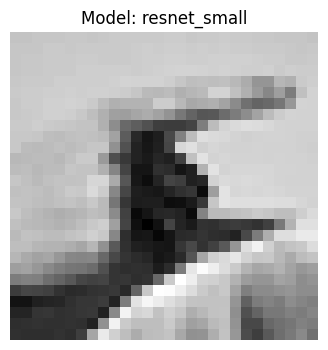

In [20]:
plt.figure(figsize=(4, 4))
plt.imshow(testImage.reshape(28, 28), cmap='gray')
plt.title(f'Model: {best_model_name}')
plt.xlabel(f'Prediction: {np.argmax(prediction)}, Actual: {y_valid[sample_idx]}')
plt.axis('off')
plt.show()


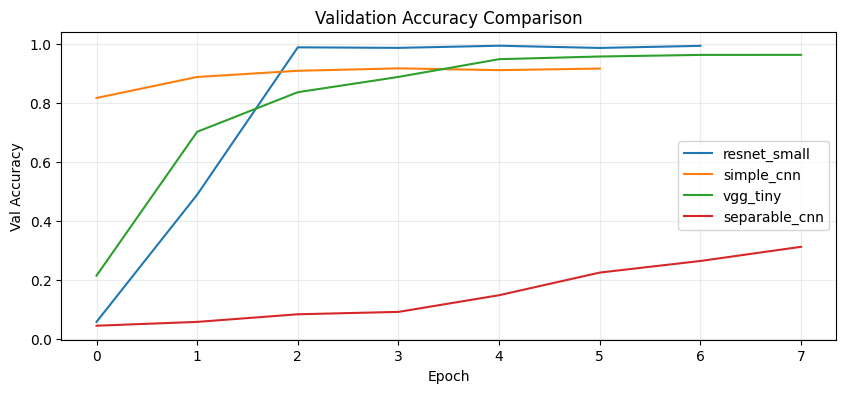

In [21]:
plt.figure(figsize=(10, 4))
for model_name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=model_name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(alpha=0.25)
plt.show()
